# Plot: therapeutic category (MOA) hit rate

Loads the MOA roll-up from `explore_leads.ipynb` (`results/leads/{organoid,single_cell}_moa_rollup.parquet`) and plots the fraction of (patient, feature) tests significant per therapeutic category.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/leads")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/leads")

moa_rollups = {
    name: pd.read_parquet(results_path / f"{name}_moa_rollup.parquet")
    for name in ["organoid", "single_cell"]
}

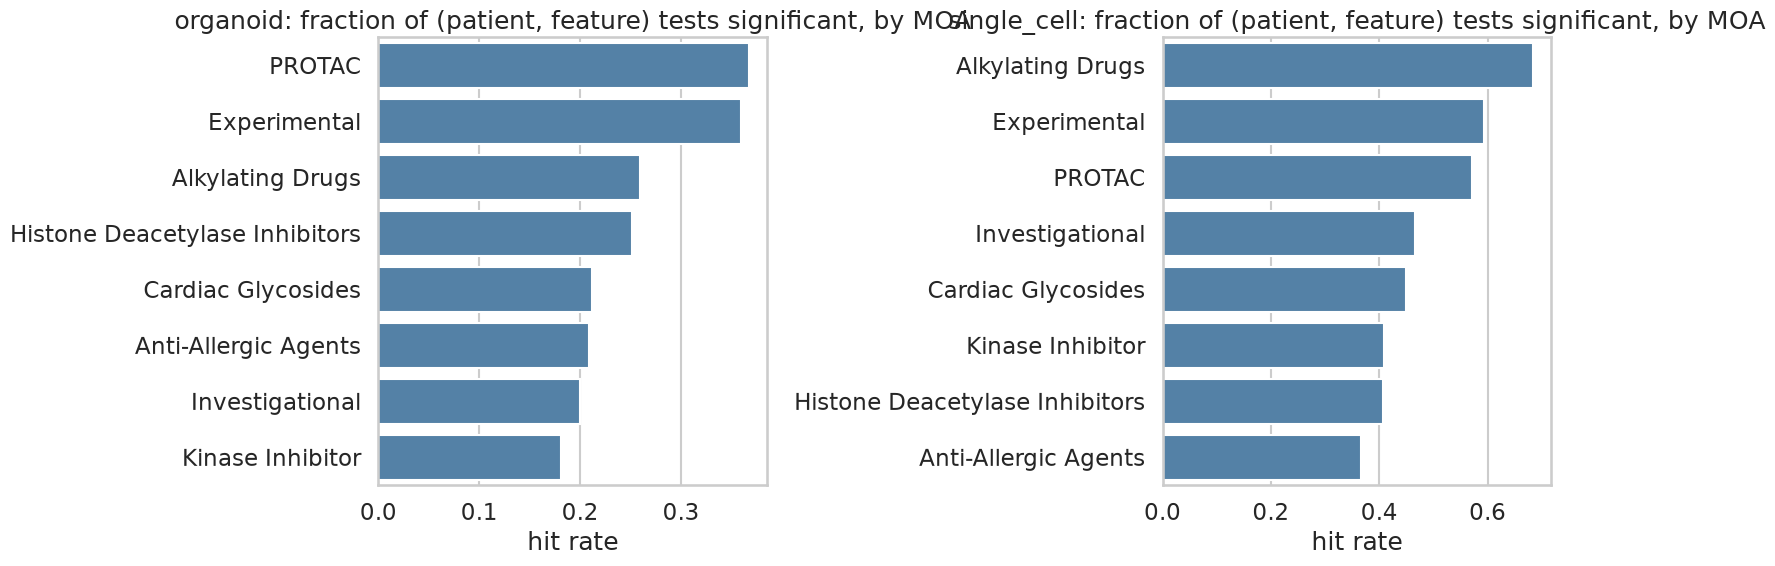

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, rollup) in zip(axes, moa_rollups.items()):
    sns.barplot(
        data=rollup, y="therapeutic_category", x="hit_rate", ax=ax, color="steelblue"
    )
    ax.set_title(f"{name}: fraction of (patient, feature) tests significant, by MOA")
    ax.set_xlabel("hit rate")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(figures_path / "moa_hit_rate.png", dpi=600, bbox_inches="tight")
plt.show()

A tight MOA cluster (many drugs in a category all hitting similar features) is a stronger lead than a single-drug hit, since it corroborates the mechanism rather than an assay artifact.